Wrote: Example_Grain_Size_gravel_classes.csv
  analysis_number  gravel  gravel_renorm     sand     silt     clay  \
0       GS-006966  3.8155       3.815813   2.8020  77.2821  16.0922   
1       GS-006967  0.0000       0.000000   8.7080  74.2795  17.0145   
2       GS-006968  2.3259       2.326209  35.1928  52.5367   9.9313   
3       GS-006969  0.0000       0.000000  63.1940  29.6275   7.1830   
4       GS-006970  2.1515       2.151879  15.9733  63.4890  18.3686   

   original_total QA_flag  sand_shep  silt_shep  clay_shep shepard_class  
0         99.9918       A   2.913400  80.354620  16.731981          silt  
1        100.0020       A   8.707826  74.278014  17.014160   clayey silt  
2         99.9867       A  36.035748  53.795074  10.169177    sandy silt  
3        100.0045       A  63.191156  29.626167   7.182677    silty sand  
4         99.9824       A  16.327459  64.896674  18.775867   clayey silt  
Saved figure: Example_Grain_Size_gravel.png


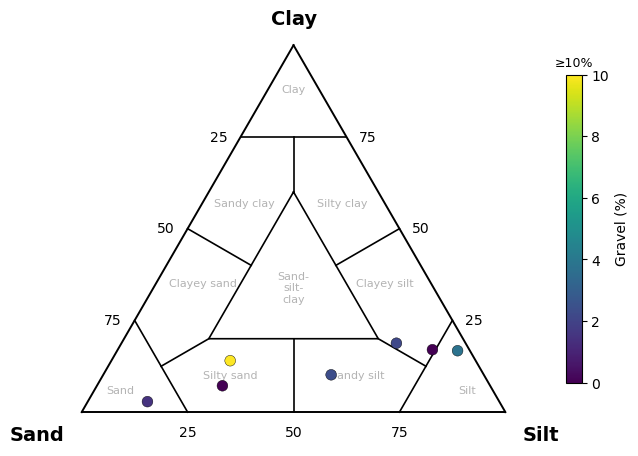

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
from matplotlib.path import Path as MplPath
import matplotlib.colors as mcolors

SQRT3 = np.sqrt(3.0)

# ============================================================
# FILE NAMES
# ============================================================
infile = Path("Example_Grain_Size_gravel.csv")
outfile = infile.with_name(f"{infile.stem}_classes.csv")

# ============================================================
# TERNARY / SHEPARD HELPERS
# ============================================================
def ternary_to_xy(sand, silt, clay):
    """
    Convert ternary percentages to x, y for:
        sand = lower left
        silt = lower right
        clay = top
    """
    sand = np.asarray(sand, dtype=float)
    silt = np.asarray(silt, dtype=float)
    clay = np.asarray(clay, dtype=float)

    total = sand + silt + clay
    if not np.allclose(total, 100.0, atol=1e-6):
        raise ValueError("Each sand/silt/clay point must sum to 100.")
    x = (silt + 0.5 * clay) / 100.0
    y = (SQRT3 / 2.0) * clay / 100.0
    return x, y


def draw_segment(ax, p1, p2, **kwargs):
    x1, y1 = ternary_to_xy(*p1)
    x2, y2 = ternary_to_xy(*p2)
    ax.plot([x1, x2], [y1, y2], **kwargs)


def draw_polygon(ax, points, **kwargs):
    pts = np.asarray(points, dtype=float)
    x, y = ternary_to_xy(pts[:, 0], pts[:, 1], pts[:, 2])
    ax.plot(np.r_[x, x[0]], np.r_[y, y[0]], **kwargs)


def add_text_ternary(ax, sand, silt, clay, text, fs=8, color="0.7"):
    x, y = ternary_to_xy(sand, silt, clay)
    ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=color)


def ternary_polygon_to_xy(points):
    pts = np.asarray(points, dtype=float)
    x, y = ternary_to_xy(pts[:, 0], pts[:, 1], pts[:, 2])
    return np.column_stack([x, y])


# ============================================================
# SHEPARD POLYGONS FROM THE AGREED BOUNDARIES
# ============================================================
def build_shepard_polygons():
    """
    Polygons follow the linework we converged on in chat.
    """
    polygons = {
        "sand": [
            (100, 0, 0),
            (75, 25, 0),
            (75, 0, 25),
        ],
        "silt": [
            (0, 100, 0),
            (0, 75, 25),
            (25, 75, 0),
        ],
        "clay": [
            (0, 0, 100),
            (25, 0, 75),
            (0, 25, 75),
        ],
        "silty sand": [
            (75, 25, 0),
            (50, 50, 0),
            (40, 40, 20),
            (60, 20, 20),
            (75, 12.5, 12.5),
        ],
        "sandy silt": [
            (25, 75, 0),
            (12.5, 75, 12.5),
            (20, 60, 20),
            (40, 40, 20),
            (50, 50, 0),
        ],
        "clayey sand": [
            (75, 0, 25),
            (75, 12.5, 12.5),
            (60, 20, 20),
            (40, 20, 40),
            (50, 0, 50),
        ],
        "clayey silt": [
            (0, 75, 25),
            (0, 50, 50),
            (20, 40, 40),
            (20, 60, 20),
            (12.5, 75, 12.5),
        ],
        "sandy clay": [
            (25, 0, 75),
            (12.5, 12.5, 75),
            (20, 20, 60),
            (40, 20, 40),
            (50, 0, 50),
        ],
        "silty clay": [
            (0, 25, 75),
            (0, 50, 50),
            (20, 40, 40),
            (20, 20, 60),
            (12.5, 12.5, 75),
        ],
        "sand-silt-clay": [
            (60, 20, 20),
            (20, 60, 20),
            (20, 20, 60),
        ],
    }
    return polygons


def build_polygon_paths():
    polygons = build_shepard_polygons()
    paths = {}
    for name, poly in polygons.items():
        xy = ternary_polygon_to_xy(poly)
        paths[name] = MplPath(xy)
    return paths


def classify_shepard_sample(sand, silt, clay, polygon_paths):
    """
    Classify one renormalized sand/silt/clay sample.
    Boundary points are included using a tiny positive radius.
    """
    total = sand + silt + clay
    if not np.isclose(total, 100.0, atol=1e-6):
        return "unclassified"

    x, y = ternary_to_xy(sand, silt, clay)
    pt = (float(x), float(y))

    # Order chosen to handle shared edges reasonably.
    class_order = [
        "sand-silt-clay",
        "sand",
        "silt",
        "clay",
        "silty sand",
        "sandy silt",
        "clayey sand",
        "clayey silt",
        "sandy clay",
        "silty clay",
    ]

    for cls in class_order:
        if polygon_paths[cls].contains_point(pt, radius=1e-12):
            return cls

    return "unclassified"


# ============================================================
# NORMALIZATION / QA
# ============================================================
def prepare_grain_size_data(df, tol_pct=1.5):
    """
    Handles optional gravel column.

    QA flag:
        A = original input total within 100 +/- tol_pct
        N = not within tolerance

    Processing:
        1. Check original total (with gravel if present).
        2. Renormalize all present fractions to sum to 100.
        3. If gravel exists, preserve it as gravel_renorm.
        4. Renormalize sand/silt/clay alone to sum to 100 for Shepard work.
    """
    df = df.copy()

    required = ["analysis_number", "sand", "silt", "clay"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Input file is missing required columns: {missing}")

    has_gravel = "gravel" in df.columns

    use_cols_all = ["sand", "silt", "clay"] + (["gravel"] if has_gravel else [])
    df[use_cols_all] = df[use_cols_all].apply(pd.to_numeric, errors="coerce")

    if df[use_cols_all].isna().any().any():
        bad_rows = df.index[df[use_cols_all].isna().any(axis=1)].tolist()
        raise ValueError(f"Non-numeric or missing grain-size values in rows: {bad_rows}")

    # Original totals used for QA flag
    df["original_total"] = df[use_cols_all].sum(axis=1)
    df["QA_flag"] = np.where(np.abs(df["original_total"] - 100.0) <= tol_pct, "A", "N")

    bad = df["QA_flag"] == "N"
    if bad.any():
        msg = [f"Rows in {infile.name} are outside 100 +/- {tol_pct}% before renormalization:"]
        for i in df.index[bad]:
            pieces = [f"row {i}", f"analysis_number={df.loc[i, 'analysis_number']}"]
            pieces += [f"{c}={df.loc[i, c]}" for c in use_cols_all]
            pieces.append(f"sum={df.loc[i, 'original_total']:.3f}")
            msg.append("  " + ", ".join(pieces))
        warnings.warn("\n".join(msg))

    # Avoid divide-by-zero
    zero_total = np.isclose(df["original_total"].values, 0.0)
    if zero_total.any():
        bad_ids = df.loc[zero_total, "analysis_number"].tolist()
        raise ValueError(f"Rows with zero total grain fraction cannot be normalized: {bad_ids}")

    # Step 1: renormalize all present fractions to sum to 100
    for c in use_cols_all:
        df[f"{c}_renorm_all"] = 100.0 * df[c] / df["original_total"]

    # Keep gravel information if present
    if has_gravel:
        df["gravel_renorm"] = df["gravel_renorm_all"]
        sand_silt_clay_total = (
            df["sand_renorm_all"] + df["silt_renorm_all"] + df["clay_renorm_all"]
        )
    else:
        df["gravel_renorm"] = 0.0
        sand_silt_clay_total = (
            df["sand_renorm_all"] + df["silt_renorm_all"] + df["clay_renorm_all"]
        )

    # Step 2: renormalize sand/silt/clay to sum to 100 for Shepard
    zero_ssc = np.isclose(sand_silt_clay_total.values, 0.0)
    if zero_ssc.any():
        bad_ids = df.loc[zero_ssc, "analysis_number"].tolist()
        raise ValueError(f"Rows with zero sand+silt+clay cannot be plotted/classified: {bad_ids}")

    df["sand_shep"] = 100.0 * df["sand_renorm_all"] / sand_silt_clay_total
    df["silt_shep"] = 100.0 * df["silt_renorm_all"] / sand_silt_clay_total
    df["clay_shep"] = 100.0 * df["clay_renorm_all"] / sand_silt_clay_total

    return df, has_gravel


# ============================================================
# PLOT
# ============================================================
def plot_simple_shepard(
    df_points=None,
    has_gravel=False,
    figsize=(8, 8),
    marker_size=56,
    label_points=False,
    label_fs=7,
    label_offset=(0.008, 0.008),
):
    fig, ax = plt.subplots(figsize=figsize)

    # Outer triangle
    draw_segment(ax, (100, 0, 0), (0, 100, 0), color="k", lw=1.4)
    draw_segment(ax, (100, 0, 0), (0, 0, 100), color="k", lw=1.4)
    draw_segment(ax, (0, 100, 0), (0, 0, 100), color="k", lw=1.4)

    # Primary boundaries
    draw_segment(ax, (75, 0, 25), (75, 25, 0), color="k", lw=1.2)
    draw_segment(ax, (25, 75, 0), (0, 75, 25), color="k", lw=1.2)
    draw_segment(ax, (0, 25, 75), (25, 0, 75), color="k", lw=1.2)

    # Inner triangle
    inner_triangle = [(20, 20, 60), (60, 20, 20), (20, 60, 20)]
    draw_polygon(ax, inner_triangle, color="k", lw=1.2)

    # Connecting segments
    draw_segment(ax, (75, 12.5, 12.5), (60, 20, 20), color="k", lw=1.2)
    draw_segment(ax, (12.5, 75, 12.5), (20, 60, 20), color="k", lw=1.2)
    draw_segment(ax, (12.5, 12.5, 75), (20, 20, 60), color="k", lw=1.2)

    draw_segment(ax, (50, 0, 50), (40, 20, 40), color="k", lw=1.2)
    draw_segment(ax, (50, 50, 0), (40, 40, 20), color="k", lw=1.2)
    draw_segment(ax, (0, 50, 50), (20, 40, 40), color="k", lw=1.2)

    # Class labels (light gray)
    add_text_ternary(ax, 88, 6, 6, "Sand")
    add_text_ternary(ax, 6, 88, 6, "Silt")
    add_text_ternary(ax, 6, 6, 88, "Clay")

    add_text_ternary(ax, 60, 30, 10, "Silty sand")
    add_text_ternary(ax, 30, 60, 10, "Sandy silt")

    add_text_ternary(ax, 54, 11, 35, "Clayey sand")
    add_text_ternary(ax, 11, 54, 35, "Clayey silt")

    add_text_ternary(ax, 33, 10, 57, "Sandy clay")
    add_text_ternary(ax, 10, 33, 57, "Silty clay")

    add_text_ternary(ax, 33, 33, 34, "Sand-\nsilt-\nclay")

    # Plot points
    cbar = None
    if df_points is not None and len(df_points) > 0:
        x, y = ternary_to_xy(
            df_points["sand_shep"].values,
            df_points["silt_shep"].values,
            df_points["clay_shep"].values,
        )

        if has_gravel:
            norm = mcolors.Normalize(vmin=0, vmax=10) # limit range of gravel colors
            sc = ax.scatter(
                x, y,
                c=df_points["gravel_renorm"].values,
                s=marker_size,
                cmap= "viridis", #"cividis",
                norm = norm,
                edgecolor="k",
                linewidth=0.3,
                zorder=5,
            )
            cbar = plt.colorbar(sc, ax=ax, shrink=0.5, pad=0.03)
            cbar.set_label("Gravel (%)")
            cbar.set_ticks([0, 2, 4, 6, 8, 10]) 
            cbar.ax.set_title("≥10%", fontsize=9, pad=6)
        else:
            ax.scatter(
                x, y,
                s=marker_size,
                color="k",
                zorder=5,
            )

        if label_points:
            dx, dy = label_offset
            for xi, yi, label in zip(x, y, df_points["analysis_number"]):
                ax.text(
                    xi + dx,
                    yi + dy,
                    str(label),
                    fontsize=label_fs,
                    ha="left",
                    va="bottom",
                    color="k",
                )

    # Axis labels outside
    ax.text(-0.04, -0.03, "Sand", ha="right", va="top",
            fontsize=14, fontweight="bold")
    ax.text(1.04, -0.03, "Silt", ha="left", va="top",
            fontsize=14, fontweight="bold")
    ax.text(0.50, SQRT3 / 2 + 0.04, "Clay", ha="center", va="bottom",
            fontsize=14, fontweight="bold")

    # Tick labels
    for silt in [25, 50, 75]:
        sand = 100 - silt
        x, y = ternary_to_xy(sand, silt, 0)
        ax.text(x, y - 0.03, f"{silt}", ha="center", va="top", fontsize=10)

    for clay in [25, 50, 75]:
        sand = 100 - clay
        x, y = ternary_to_xy(sand, 0, clay)
        ax.text(x - 0.03, y, f"{sand}", ha="right", va="center", fontsize=10)

    for clay in [25, 50, 75]:
        x, y = ternary_to_xy(0, 100 - clay, clay)
        ax.text(x + 0.03, y, f"{clay}", ha="left", va="center", fontsize=10)

    ax.set_aspect("equal")
    ax.set_xlim(-0.10, 1.10)
    ax.set_ylim(-0.08, SQRT3 / 2 + 0.08)
    ax.axis("off")

    return fig, ax, cbar


# ============================================================
# READ, PREPARE, CLASSIFY, WRITE, PLOT
# ============================================================
if not infile.exists():
    raise FileNotFoundError(f"Could not find input file: {infile}")

df = pd.read_csv(infile)

df, has_gravel = prepare_grain_size_data(df, tol_pct=1.5)

polygon_paths = build_polygon_paths()

df["shepard_class"] = [
    classify_shepard_sample(sand, silt, clay, polygon_paths)
    for sand, silt, clay in zip(df["sand_shep"], df["silt_shep"], df["clay_shep"])
]

# Choose output columns
out_cols = ["analysis_number"]
if has_gravel:
    out_cols += ["gravel", "gravel_renorm"]
out_cols += [
    "sand", "silt", "clay",
    "original_total", "QA_flag",
    "sand_shep", "silt_shep", "clay_shep",
    "shepard_class",
]

# Keep only columns that actually exist
out_cols = [c for c in out_cols if c in df.columns]
df[out_cols].to_csv(outfile, index=False)

print(f"Wrote: {outfile}")
print(df[out_cols].head())

# Toggle point labels here
fig, ax, cbar = plot_simple_shepard(
    df_points=df,
    has_gravel=has_gravel,
    figsize=(8, 8),
    marker_size=60,
    label_points=False,   # set True to label with analysis_number
    label_fs=7,
    label_offset=(0.008, 0.008),
)

# --------------------------------------------------------
# SAVE FIGURE
# --------------------------------------------------------
png_file = infile.with_suffix(".png")

fig.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved figure: {png_file}")

plt.show()